In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import astropy.units as u
import importlib
import statmorph

import utils.data as datutils
import utils.image as imutils
import utils.file as futils
import utils.plots as plots

In [5]:
importlib.reload(futils)

<module 'utils.file' from '/Users/kabelo/clusters/utils/file.py'>

In [12]:
def morph(map_dir, annulus=False, r1=1*u.Mpc, r2=50*u.kpc):
    finished_ids = []
    morphs_list = []
    files_list = sorted(os.listdir(map_dir))
    for file in files_list:
        id = futils.find_id(file)
        r1, _ = futils.get_virial_radius(id)
        print(f"Rvir for region {id}: {r1}")
        if id in finished_ids:
            continue
        else:
            print(f"Processing region {id}")
            finished_ids.append(id)

        map = futils.load_map(file, map_dir)
        if map is None:
            print(f"Skipping region {id}: no map")
            continue

        if annulus:
            rad2 = r2.to(u.kpc).value
            rad1 = r1.to(u.Mpc).value
        else:
            rad1 = r1.to(u.Mpc).value

        pixr1 = datutils.real2pix(r1, map)
        pixr2 = datutils.real2pix(r2, map)
        center = (int(len(map[1])//2), int(len(map[0])//2))
        if annulus:
            segmap = imutils.annular_mask(map, center, pixr2, pixr1)
        else:
            segmap = imutils.circular_segmap(map, center, pixr1)

        fig, axs = plt.subplots(1, 1)
        plots.display_img(map, axs, mask=segmap)
        plt.show()
        morph = statmorph.source_morphology(map, segmap, gain=2.25)
        morphs_list.append((id, morph[0]))
        print(f'{file} done')

        if len(morphs_list) % 20 == 0:
            if annulus:
                name = f'results/gadgetx3k_{len(morphs_list)}_rin{rad2}kpc_rout{rad1}Mpc.csv'
                sm_df = futils.create_morph_df(morphs_list,
                                                 name=name,
                                                 save=True)
            else:
                name = f'results/gadgetx3k_{len(morphs_list)}_{rad1}Mpc.csv'
                sm_df = futils.create_morph_df(morphs_list, 
                                                 name=name, 
                                                 save=True)

    if annulus:
        name = f'tests/gadgetx3k_{len(morphs_list)}_rin{rad2}kpc_rout{rad1}Mpc_.csv'
        sm_df = futils.create_morph_df(morphs_list,
                                            name=name,
                                            save=True)
    else:
        name = f'tests/gadgetx3k_{len(morphs_list)}_{rad1}Mpc_.csv'
        sm_df = futils.create_morph_df(morphs_list,
                                            name=name,
                                            save=True)

    return

/Users/kabelo/clusters/utils/file.py:219: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  ahf_df = pd.read_csv(file, sep=r'\s+', index_col=False)


Rvir for region 1: 2242.26 kpc
Processing region 1


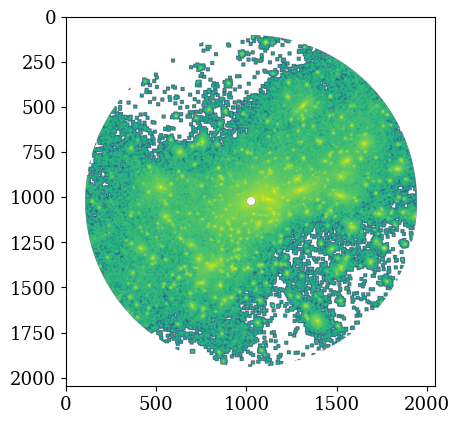

/Users/kabelo/clusters/utils/file.py:219: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  ahf_df = pd.read_csv(file, sep=r'\s+', index_col=False)


bcg_0001_125_2.fits done
Rvir for region 2: 2145.07 kpc
Processing region 2


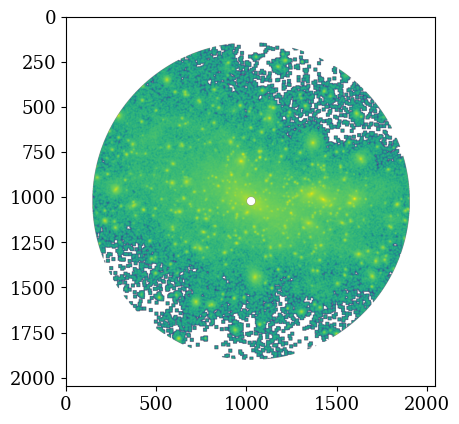

bcg_0002_125_2.fits done
Rvir for region 3: 2030.74 kpc
Processing region 3


/Users/kabelo/clusters/utils/file.py:219: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  ahf_df = pd.read_csv(file, sep=r'\s+', index_col=False)


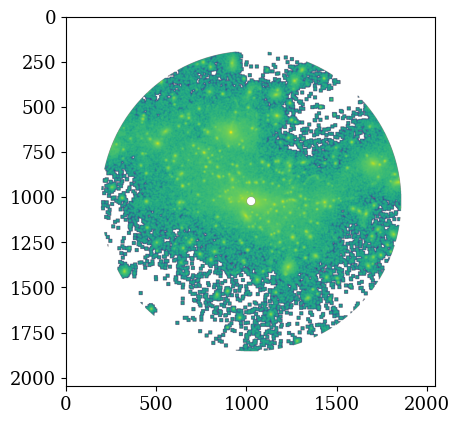

bcg_0003_125_2.fits done


In [13]:
morph('data/gadgetx3k/maps/tmp/', annulus=True, r1=1*u.Mpc, r2=60*u.kpc)